### **DQN for LunarLander - SEED for Imitation Learning**

This notebook implements a **simple and educational DQN agent** for a discrete-control task: `LunarLander-v3`.

DQN is an off-policy value-based algorithm. It learns:

1. A **Q-network** $Q_\theta(s,a)$ that estimates the action-value function.
2. A **target network** $Q_{\theta'}$ updated softly (Polyak) to stabilize training.
3. An **epsilon-greedy** behavior policy that decays exploration over time.

The Bellman target is:

\[
y = r + \gamma (1 - d) \, \max_{a'} Q_{\theta'}(s', a')
\]

and the loss is MSE between $Q_\theta(s,a)$ and $y$.

**Expected results**

Reward < 0       very poor / not trained <br>
0 - 100          learning to hover <br>
100 - 200        decent landing <br>
200+             solved (official threshold) <br>
250+             very strong performance<br>


In [1]:
# If needed, install dependencies:
# !pip install "gymnasium[box2d]" matplotlib torch

import random
from collections import deque
from dataclasses import dataclass

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# To force CPU, uncomment:
# device = torch.device("cpu")

@dataclass
class Config:
    ENV_NAME: str = "LunarLander-v3"
    MAX_EPISODES: int = 600
    MAX_STEPS: int = 1000
    REPLAY_SIZE: int = 100_000
    BATCH_SIZE: int = 128
    GAMMA: float = 0.99
    TAU: float = 0.005          # soft target update
    LR: float = 5e-4
    HIDDEN_DIM: int = 128
    EPS_START: float = 1.0
    EPS_END: float = 0.05
    EPS_DECAY: float = 0.995    # multiplicative per-episode
    START_STEPS: int = 1_000    # random transitions before training begins
    UPDATE_EVERY: int = 1
    ROLLING_WINDOW: int = 20
    SOLVED_REWARD: float = 200.0

cfg = Config()
cfg


Device: cuda


Config(ENV_NAME='LunarLander-v3', MAX_EPISODES=600, MAX_STEPS=1000, REPLAY_SIZE=100000, BATCH_SIZE=128, GAMMA=0.99, TAU=0.005, LR=0.0005, HIDDEN_DIM=128, EPS_START=1.0, EPS_END=0.05, EPS_DECAY=0.995, START_STEPS=1000, UPDATE_EVERY=1, ROLLING_WINDOW=20, SOLVED_REWARD=200.0)

`LunarLander-v3` has:

- an 8-dim continuous observation (position, velocity, angle, angular vel., leg contacts);
- 4 discrete actions: do nothing, fire left, fire main, fire right;
- reward shaping for landing softly between the flags. Reaching the pad gives +100/+140.


In [14]:
env = gym.make(cfg.ENV_NAME)
eval_env = gym.make(cfg.ENV_NAME)

state_dim = env.observation_space.shape[0]
n_actions = env.action_space.n

print("State dimension:", state_dim)
print("Number of actions:", n_actions)


State dimension: 8
Number of actions: 4


## 3. Replay buffer

DQN is **off-policy**, so it stores transitions:

\[
(s_t, a_t, r_t, s_{t+1}, done)
\]

and samples mini-batches randomly to decorrelate updates.


In [4]:
class ReplayBuffer:
    def __init__(self, max_size):
        self.buffer = deque(maxlen=max_size)

    def add(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.tensor(np.array(states), dtype=torch.float32, device=device)
        actions = torch.tensor(np.array(actions), dtype=torch.long, device=device).unsqueeze(1)
        rewards = torch.tensor(np.array(rewards), dtype=torch.float32, device=device).unsqueeze(1)
        next_states = torch.tensor(np.array(next_states), dtype=torch.float32, device=device)
        dones = torch.tensor(np.array(dones), dtype=torch.float32, device=device).unsqueeze(1)

        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)


#### **4. Q-network**

A simple MLP that maps a state to one Q-value per discrete action: 

$ Q_\theta(s) \in \mathbb{R}^{|\mathcal{A}|}$

We pick actions with `argmax`.


In [5]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, n_actions, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_actions),
        )

    def forward(self, state):
        return self.net(state)


#### **DQN Agent**

The DQN update has three main parts:

### Critic update

$y = r + \gamma (1 - d) \, \max_{a'} Q_{\theta'}(s', a')$

### Action selection

Epsilon-greedy:

$a = \begin{cases} \text{random}, & \text{w.p. } \varepsilon \\ \arg\max_a Q_\theta(s,a), & \text{otherwise} \end{cases}$

### Target network update (soft / Polyak)

$\theta' \leftarrow (1-\tau)\theta' + \tau\theta$


In [6]:
class DQNAgent:
    def __init__(self, state_dim, n_actions, config):
        self.cfg = config
        self.n_actions = n_actions

        self.q = QNetwork(state_dim, n_actions, config.HIDDEN_DIM).to(device)
        self.q_target = QNetwork(state_dim, n_actions, config.HIDDEN_DIM).to(device)
        self.q_target.load_state_dict(self.q.state_dict())

        self.optimizer = optim.Adam(self.q.parameters(), lr=config.LR)
        self.replay_buffer = ReplayBuffer(config.REPLAY_SIZE)

        self.epsilon = config.EPS_START

    def select_action(self, state, evaluate=False):
        # Greedy at eval time, epsilon-greedy during training
        if (not evaluate) and (random.random() < self.epsilon):
            return random.randrange(self.n_actions)

        state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
        with torch.no_grad():
            q_values = self.q(state_t)
        return int(q_values.argmax(dim=1).item())

    def decay_epsilon(self):
        self.epsilon = max(self.cfg.EPS_END, self.epsilon * self.cfg.EPS_DECAY)

    def update(self):
        if len(self.replay_buffer) < self.cfg.BATCH_SIZE:
            return None

        states, actions, rewards, next_states, dones = self.replay_buffer.sample(self.cfg.BATCH_SIZE)

        # Current Q(s, a)
        q_pred = self.q(states).gather(1, actions)

        # Bellman target with frozen target network
        with torch.no_grad():
            q_next = self.q_target(next_states).max(dim=1, keepdim=True)[0]
            target_q = rewards + (1 - dones) * self.cfg.GAMMA * q_next

        loss = F.mse_loss(q_pred, target_q)

        self.optimizer.zero_grad()
        loss.backward()
        # Gradient clipping helps stability
        torch.nn.utils.clip_grad_norm_(self.q.parameters(), max_norm=10.0)
        self.optimizer.step()

        self.soft_update(self.q, self.q_target)

        return {"q_loss": loss.item(), "mean_q": q_pred.mean().item()}

    def soft_update(self, source, target):
        for source_param, target_param in zip(source.parameters(), target.parameters()):
            target_param.data.copy_(
                self.cfg.TAU * source_param.data + (1.0 - self.cfg.TAU) * target_param.data
            )


#### **Evaluation function**

Run the policy deterministically (greedy, no epsilon) for a few episodes and return mean / std reward.


In [7]:
def evaluate_policy(agent, env, episodes=5):
    rewards = []
    for _ in range(episodes):
        state, _ = env.reset()
        total = 0.0
        done = False
        while not done:
            action = agent.select_action(state, evaluate=True)
            state, reward, terminated, truncated, _ = env.step(action)
            total += reward
            done = terminated or truncated
        rewards.append(total)
    return float(np.mean(rewards)), float(np.std(rewards))


#### **Training loop**

Standard DQN loop:

1. Step the env with epsilon-greedy actions.
2. Store transitions in the replay buffer.
3. After enough transitions, update Q on each step.
4. Decay epsilon each episode.
5. Periodically evaluate greedily.


In [8]:
%%time
agent = DQNAgent(state_dim, n_actions, cfg)

all_rewards = []
rolling = deque(maxlen=cfg.ROLLING_WINDOW)
q_losses = []
total_steps = 0
solved_episode = None

for episode in range(1, cfg.MAX_EPISODES + 1):
    state, _ = env.reset(seed=SEED + episode)
    ep_reward = 0.0

    for step in range(cfg.MAX_STEPS):
        # Pure random exploration at the very beginning so the buffer has variety
        if total_steps < cfg.START_STEPS:
            action = env.action_space.sample()
        else:
            action = agent.select_action(state, evaluate=False)

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        agent.replay_buffer.add(state, action, reward, next_state, float(terminated))

        state = next_state
        ep_reward += reward
        total_steps += 1

        if total_steps >= cfg.START_STEPS and (total_steps % cfg.UPDATE_EVERY == 0):
            info = agent.update()
            if info is not None:
                q_losses.append(info["q_loss"])

        if done:
            break

    agent.decay_epsilon()
    all_rewards.append(ep_reward)
    rolling.append(ep_reward)
    rolling_avg = float(np.mean(rolling))

    print(
        f"Episode {episode:4d}/{cfg.MAX_EPISODES} | Reward: {ep_reward:8.2f} | "
        f"Rolling Avg: {rolling_avg:8.2f} | eps: {agent.epsilon:.3f} | Buffer: {len(agent.replay_buffer):6d}"
    )

    if episode % 25 == 0:
        eval_mean, eval_std = evaluate_policy(agent, eval_env, episodes=3)
        print(f"  Evaluation over 3 episodes: {eval_mean:.2f} ± {eval_std:.2f}")

    # Early stopping: solved if rolling avg stays above the official threshold
    if rolling_avg >= cfg.SOLVED_REWARD and len(rolling) == cfg.ROLLING_WINDOW:
        solved_episode = episode
        print(f"\nSolved! Rolling avg over last {cfg.ROLLING_WINDOW} episodes "
              f"reached {rolling_avg:.2f} at episode {episode}.")
        break


Episode    1/600 | Reward:   -64.46 | Rolling Avg:   -64.46 | eps: 0.995 | Buffer:     73
Episode    2/600 | Reward:  -422.97 | Rolling Avg:  -243.72 | eps: 0.990 | Buffer:    169
Episode    3/600 | Reward:  -104.98 | Rolling Avg:  -197.47 | eps: 0.985 | Buffer:    247
Episode    4/600 | Reward:   -93.23 | Rolling Avg:  -171.41 | eps: 0.980 | Buffer:    312
Episode    5/600 | Reward:  -367.55 | Rolling Avg:  -210.64 | eps: 0.975 | Buffer:    422
Episode    6/600 | Reward:   -61.26 | Rolling Avg:  -185.74 | eps: 0.970 | Buffer:    509
Episode    7/600 | Reward:  -136.47 | Rolling Avg:  -178.70 | eps: 0.966 | Buffer:    622
Episode    8/600 | Reward:   -84.84 | Rolling Avg:  -166.97 | eps: 0.961 | Buffer:    690
Episode    9/600 | Reward:  -391.56 | Rolling Avg:  -191.92 | eps: 0.956 | Buffer:    784
Episode   10/600 | Reward:   -89.85 | Rolling Avg:  -181.72 | eps: 0.951 | Buffer:    848
Episode   11/600 | Reward:  -134.08 | Rolling Avg:  -177.39 | eps: 0.946 | Buffer:    932
Episode   

#### **Learning Curve and Loss Plotting**


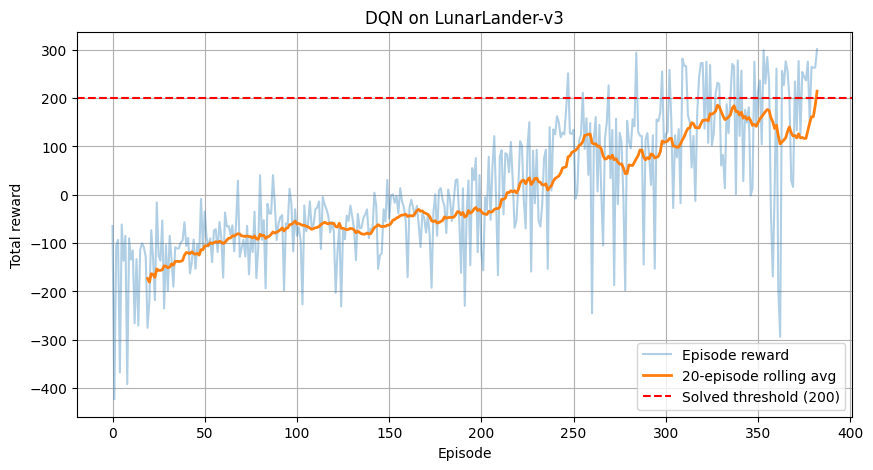

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(all_rewards, alpha=0.35, label="Episode reward")
if len(all_rewards) >= cfg.ROLLING_WINDOW:
    rolling_arr = np.convolve(
        all_rewards, np.ones(cfg.ROLLING_WINDOW) / cfg.ROLLING_WINDOW, mode="valid"
    )
    plt.plot(
        range(cfg.ROLLING_WINDOW - 1, cfg.ROLLING_WINDOW - 1 + len(rolling_arr)),
        rolling_arr,
        label=f"{cfg.ROLLING_WINDOW}-episode rolling avg",
        linewidth=2,
    )
plt.axhline(cfg.SOLVED_REWARD, color="red", linestyle="--", label="Solved threshold (200)")
plt.xlabel("Episode")
plt.ylabel("Total reward")
plt.title("DQN on LunarLander-v3")
plt.grid(True)
plt.legend()
plt.show()


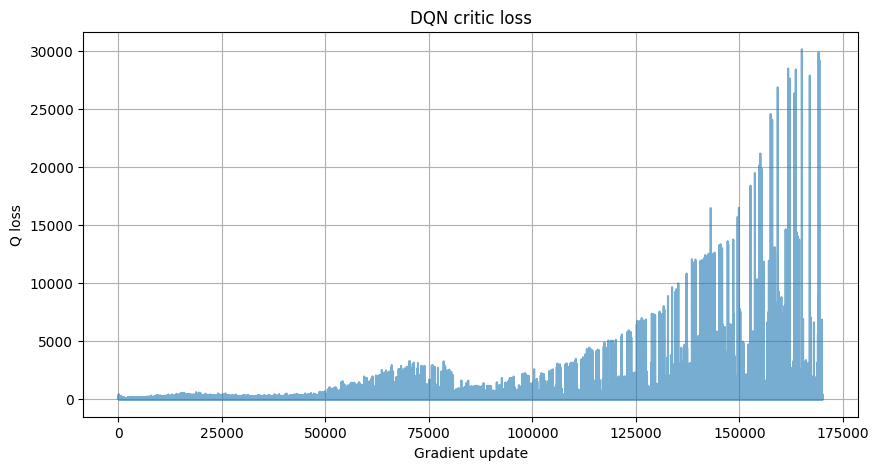

In [10]:
if len(q_losses) > 0:
    plt.figure(figsize=(10, 5))
    plt.plot(q_losses, alpha=0.6)
    plt.xlabel("Gradient update")
    plt.ylabel("Q loss")
    plt.title("DQN critic loss")
    plt.grid(True)
    plt.show()


#### **Result Evaluation**

In [11]:
eval_mean, eval_std = evaluate_policy(agent, eval_env, episodes=10)
print(f"Final deterministic evaluation: {eval_mean:.2f} ± {eval_std:.2f}")


Final deterministic evaluation: 241.99 ± 53.34


#### **Saving policy to be used in the future in an Imitation Learning Process**


In [12]:
torch.save({
    "q": agent.q.state_dict(),
    "config": cfg.__dict__,
}, "dqn_lunarlander_checkpoint.pt")

print("Saved checkpoint: dqn_lunarlander_checkpoint.pt")


Saved checkpoint: dqn_lunarlander_checkpoint.pt


#### **Rendering episode asa a gif**

Headless-friendly: sets `MUJOCO_GL` / `PYOPENGL_PLATFORM` for off-screen rendering. 
LunarLander uses Box2D so this isn't strictly required, but it doesn't hurt.


Rendered episode reward: 253.04
Number of frames: 296
Saved GIF to: ./LunarLander_DQN.gif


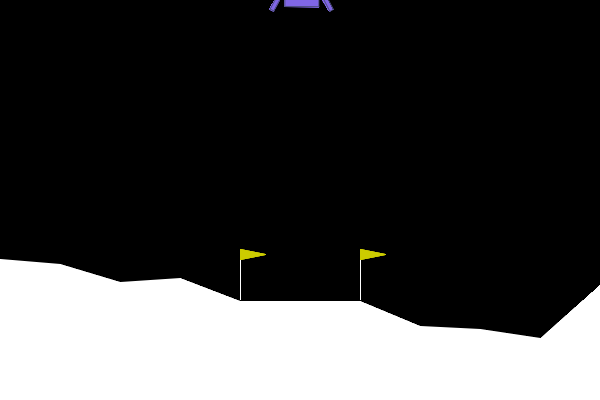

In [13]:
import os
os.environ.setdefault("MUJOCO_GL", "egl")
os.environ.setdefault("PYOPENGL_PLATFORM", os.environ["MUJOCO_GL"])

from PIL import Image
from IPython.display import Image as IPyImage, display

render_env = gym.make(cfg.ENV_NAME, render_mode="rgb_array")
frames = []

state, _ = render_env.reset(seed=SEED)
total_reward = 0.0

for step in range(cfg.MAX_STEPS):
    action = agent.select_action(state, evaluate=True)
    next_state, reward, terminated, truncated, _ = render_env.step(action)

    frame = render_env.render()
    frames.append(frame)

    total_reward += reward
    state = next_state

    if terminated or truncated:
        break

render_env.close()

print(f"Rendered episode reward: {total_reward:.2f}")
print(f"Number of frames: {len(frames)}")


def save_frames_as_gif(frames, path="./", filename="LunarLander_DQN.gif"):
    os.makedirs(path, exist_ok=True)
    images = [Image.fromarray(frame) for frame in frames]
    gif_path = os.path.join(path, filename)
    images[0].save(
        gif_path,
        save_all=True,
        append_images=images[1:],
        duration=40,
        loop=0,
    )
    print(f"Saved GIF to: {gif_path}")
    return gif_path


gif_path = save_frames_as_gif(frames, filename="LunarLander_DQN.gif")
display(IPyImage(filename=gif_path))


#### **We have the agent policy saved, and we can use it as a SEED for an IMITATION Learning**
